In [1]:
import os
os.chdir(r'C:\Users\PC\MarketPulse360')

In [2]:
# ============================================
# CELLULE 1 — Imports
# ============================================
import pandas as pd
import numpy as np
from sqlalchemy import create_engine
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv
import os

load_dotenv()
engine = create_engine(
    f"postgresql://{os.getenv('DB_USER')}:{os.getenv('DB_PASSWORD')}"
    f"@{os.getenv('DB_HOST')}:{os.getenv('DB_PORT')}/{os.getenv('DB_NAME')}"
)

In [3]:
# ============================================
# CELLULE 2 — RFM Analysis
# ============================================
df = pd.read_sql("""
    SELECT
        fo.customer_id,
        dc.customer_unique_id,
        dc.customer_state,
        COUNT(DISTINCT fo.order_id)      AS frequency,
        SUM(fo.product_price)            AS monetary,
        MAX(fo.order_date)               AS last_order_date
    FROM fact_orders fo
    JOIN dim_customers dc ON fo.customer_id = dc.customer_id
    GROUP BY fo.customer_id, dc.customer_unique_id, dc.customer_state
""", engine, parse_dates=['last_order_date'])

reference_date = df['last_order_date'].max() + pd.Timedelta(days=1)
df['recency'] = (reference_date - df['last_order_date']).dt.days

print(f"Clients uniques : {df['customer_unique_id'].nunique():,}")
df[['recency', 'frequency', 'monetary']].describe()

Clients uniques : 93,358


,recency,frequency,monetary
count,96478.000000,96478.0,96478.000000
mean,240.657559,1.0,137.646267
std,152.840161,0.0,209.773507
min,1.000000,1.0,0.850000
25%,117.000000,1.0,45.900000
50%,222.000000,1.0,86.990000
75%,350.000000,1.0,149.900000
max,714.000000,1.0,13440.000000


In [4]:
# ============================================
# CELLULE 3 — Scoring RFM
# ============================================
df['r_score'] = pd.qcut(df['recency'],   q=4, labels=[4, 3, 2, 1]).astype(int)
df['f_score'] = pd.qcut(df['frequency'].rank(method='first'), q=4, labels=[1, 2, 3, 4]).astype(int)
df['m_score'] = pd.qcut(df['monetary'],  q=4, labels=[1, 2, 3, 4]).astype(int)
df['rfm_score'] = df['r_score'] + df['f_score'] + df['m_score']

def rfm_segment(score):
    if score >= 10:   return 'Champions'
    elif score >= 8:  return 'Loyal Customers'
    elif score >= 6:  return 'Potential Loyalists'
    elif score >= 4:  return 'At Risk'
    else:             return 'Lost'

df['rfm_segment'] = df['rfm_score'].apply(rfm_segment)
print(df['rfm_segment'].value_counts())

rfm_segment
Potential Loyalists    33052
Loyal Customers        33047
Champions              15246
At Risk                13579
Lost                    1554
Name: count, dtype: int64


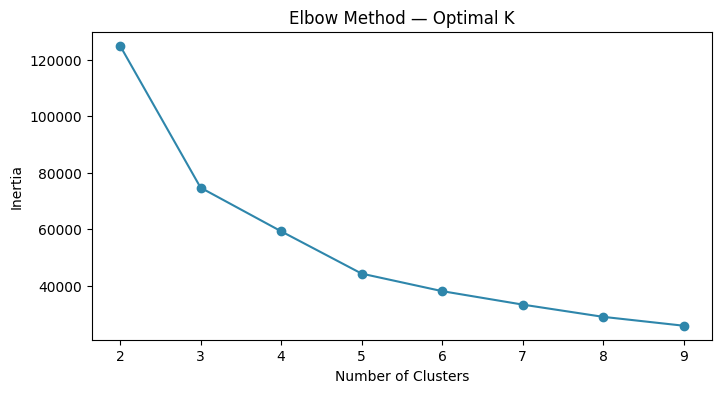

         nb_customers  avg_recency  avg_frequency  avg_monetary
cluster                                                        
0               35570        255.9            1.0         109.7
1                2691        241.3            1.0        1047.6
2               35745         88.3            1.0         113.3
3               22472        458.7            1.0         111.7


In [5]:
# ============================================
# CELLULE 4 — K-Means clustering
# ============================================
features = df[['recency', 'frequency', 'monetary']].copy()
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

# Elbow method
inertias = []
K_range = range(2, 10)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(features_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(K_range, inertias, marker='o', color='#2E86AB')
plt.title('Elbow Method — Optimal K')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.savefig('reports/elbow_method.png', dpi=150)
plt.show()

# Clustering final avec k=4
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(features_scaled)

cluster_summary = df.groupby('cluster').agg(
    nb_customers=('customer_unique_id', 'count'),
    avg_recency=('recency', 'mean'),
    avg_frequency=('frequency', 'mean'),
    avg_monetary=('monetary', 'mean')
).round(1)
print(cluster_summary)

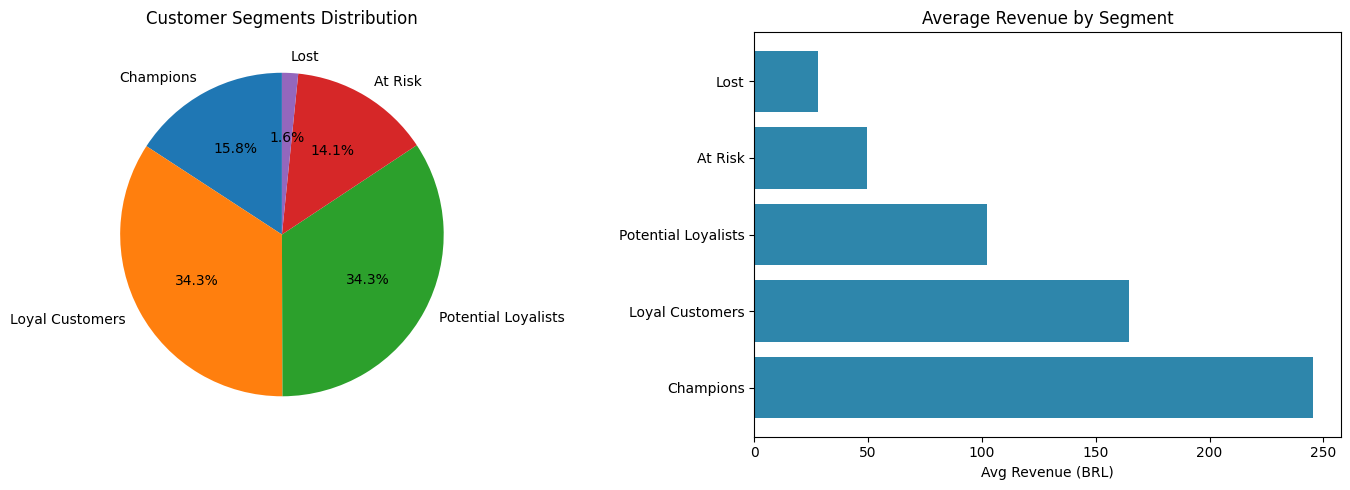

In [6]:
# ============================================
# CELLULE 5 — Visualisation segments RFM
# ============================================
segment_stats = df.groupby('rfm_segment').agg(
    count=('customer_unique_id', 'count'),
    avg_revenue=('monetary', 'mean')
).reset_index().sort_values('avg_revenue', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].pie(segment_stats['count'], labels=segment_stats['rfm_segment'], autopct='%1.1f%%', startangle=90)
axes[0].set_title('Customer Segments Distribution')
axes[1].barh(segment_stats['rfm_segment'], segment_stats['avg_revenue'], color='#2E86AB')
axes[1].set_title('Average Revenue by Segment')
axes[1].set_xlabel('Avg Revenue (BRL)')
plt.tight_layout()
plt.savefig('reports/customer_segments.png', dpi=150)
plt.show()

In [7]:
# ============================================
# CELLULE 6 — Export
# ============================================
df.to_csv('data/processed/customer_segmentation.csv', index=False)
print("✅ Segmentation exportée")

✅ Segmentation exportée
